# ZINC Non-Streaming Demo

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [7]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.5.0+cpu
CUDA available: False


In [8]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc20'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 7
DATA_LIMIT = 0.99
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
EMBEDDING_DIM = 64
MODEL_NAME = f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-s{DATA_LIMIT}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [9]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=2,
    transformer_attention_head_count=4,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=2,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules


ZINC CSV: /home/fabrizio/code/NodeField/notebooks/datasets/zinc/zinc20.csv
Loaded 69279 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc20-nonstreaming-d64-s0-99-b128-e350 model_dir=/home/fabrizio/code/NodeField/.artifacts/saved_generators


In [ ]:
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Fit target model_name=zinc20-nonstreaming-d64-s0-99-b128-e350 model_dir=/home/fabrizio/code/NodeField/.artifacts/saved_generators
Fitting model on 69279 graphs
Fitting feasibility estimator on 69279 graphs
Finished fitting feasibility estimator in 10m 16.6s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 7742460 pairs (50.00%) from 15484920 total pairs (pos=5162380, neg=10322540, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=2581190, neg=5161270, positive_ratio=0.333.
Training conditional model on 69279 graphs with up to 20 no

Sampling 7 graphs
Non-streaming ZINC samples without feasibility filtering


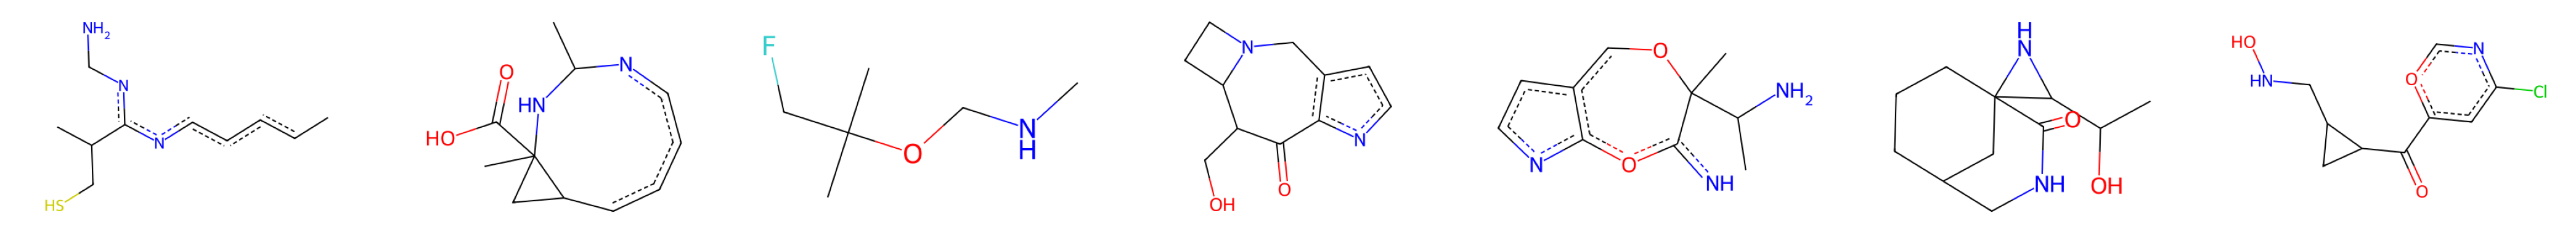

In [ ]:
raw_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=False,
)
show_molecules(raw_samples, n=7, title='Non-streaming ZINC samples without feasibility filtering')


Sampling 7 graphs
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | fulfilled_slots= 0 | pending_slots= 1 | feasible_rate=  0.0% | fulfilled_total= 0 | missing_total= 1 | attempt_time=1m 19.3s | eta=25m 05.8s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | fulfilled_slots= 0 | pending_slots= 1 | feasible_rate=  0.0% | fulfilled_total= 0 | missing_total= 1 | attempt_time=1m 38.8s | eta=26m 42.7s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | fulfilled_slots= 0 | pending_slots= 1 | feasible_rate=  0.0% | fulfilled_total= 0 | missing_total= 1 | attempt_time=   52.6s | eta=21m 47.1s
Feasibility attempt  4/20 | generated=   8 | feasible_candidates= 0 | fulfilled_slots= 0 | pending_slots= 1 | feasible_rate=  0.0% | fulfilled_total= 0 | missing_total= 1 | attempt_time=   53.4s | eta=18m 56.2s
Feasibility attempt  5/20 | generated=   8 | feasible_candidates= 0 | fulfilled_slots= 0 | pending_slots= 1 | feasible_rate=  0.0% | fulfi

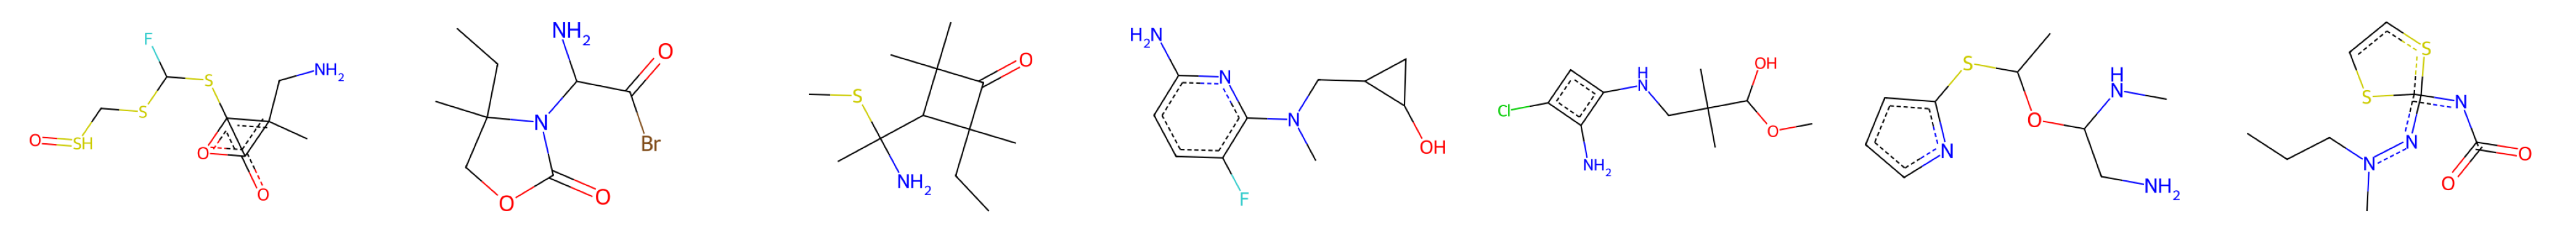

In [ ]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=7, title='Non-streaming ZINC samples with feasibility filtering')
